#Transição Energética Global (2015 - 2025)

Análise da evolução da energia renovável em diferentes países entre 2015 e 2025, explorando capacidade instalada, investimentos, impacto ambiental e comparação global.

## Pergunta do Negócio


Como diferentes países evoluíram na transição para energias renováveis e quais fatores estão associados a esse avanço?

## Objetivo

Identificar padrões de crescimento em energia renovável, comparar países e entender relações entre investimento, capacidade energética e impacto ambiental.

## Hipóteses Iníciais


- Países com mais investimentos possuem mais avaços.
- Existem diferenças significativas entre países mais desenvolvidos e menos desenvolvidos.
- O crescimento de energia limpa está associado à redção da emissão do CO².

## Importar bibliotecas

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carregar dataset

In [48]:
df=pd.read_csv("/content/energy_transition_dataset.csv")

## Estrutura da base

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          110 non-null    int64  
 1   Country                       110 non-null    object 
 2   Solar_Capacity_GW             110 non-null    float64
 3   Wind_Capacity_GW              110 non-null    float64
 4   Hydro_Capacity_GW             110 non-null    float64
 5   Biomass_Capacity_GW           110 non-null    float64
 6   Geothermal_Capacity_GW        110 non-null    float64
 7   Total_Renewable_Capacity_GW   110 non-null    float64
 8   Renewable_Energy_Percentage   110 non-null    float64
 9   CO2_Reduction_Million_Tonnes  110 non-null    float64
 10  Investment_Billion_USD        110 non-null    float64
 11  Employment_Thousand_Jobs      110 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 10.4+ KB


O dataset analisado contém 110 registros e 12 variáveis relacionadas à transição energética global entre 2015 e 2025.

As colunas incluem informações temporais (Year), geográficas (Country) e indicadores quantitativos de energia renovável, como capacidade instalada por fonte (solar, eólica, hidrelétrica, biomassa e geotérmica), capacidade total, percentual de energia renovável, redução de CO₂, investimento em energia limpa e geração de empregos.

Os dados estão estruturados com predominância de variáveis numéricas (float64), além de variáveis categóricas (object) e temporais (int64), permitindo análises comparativas entre países, evolução ao longo do tempo e correlações entre investimento, capacidade energética e impacto ambiental.

## Verificação de nulos

In [50]:
df.isnull().sum()

,0
Year,0
Country,0
Solar_Capacity_GW,0
Wind_Capacity_GW,0
Hydro_Capacity_GW,0
Biomass_Capacity_GW,0
Geothermal_Capacity_GW,0
Total_Renewable_Capacity_GW,0
Renewable_Energy_Percentage,0
CO2_Reduction_Million_Tonnes,0


O dataset não possui nenhum dado nulo

##EDA Inicial

Entendimento dos dados com visualizações simples e diretas

### Evolução global da capacidade renovável

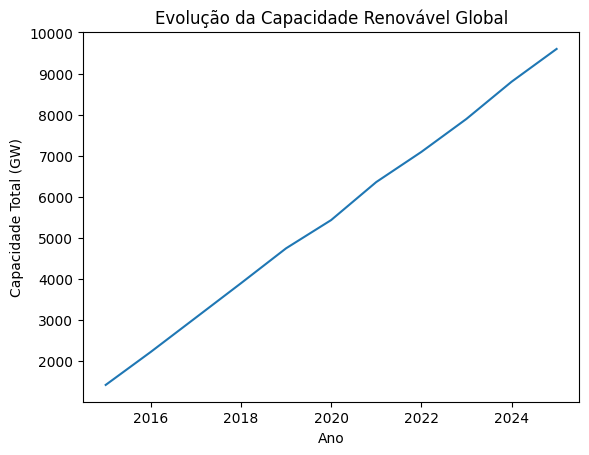

In [51]:
df.groupby("Year")["Total_Renewable_Capacity_GW"].sum().plot()
plt.title("Evolução da Capacidade Renovável Global")
plt.xlabel("Ano")
plt.ylabel("Capacidade Total (GW)")
plt.show()

In [52]:
df_evolucao_global = df.groupby("Year")["Total_Renewable_Capacity_GW"].sum().reset_index()

df_evolucao_global

,Year,Total_Renewable_Capacity_GW
0,2015,1424.52
1,2016,2227.77
2,2017,3062.65
3,2018,3898.53
4,2019,4747.66
5,2020,5435.22
6,2021,6359.56
7,2022,7092.72
8,2023,7895.53
9,2024,8799.26


O crescimento é consistente ao longo dos anos, indicando expansão acelerada da transição energética global

###Comparação entre países

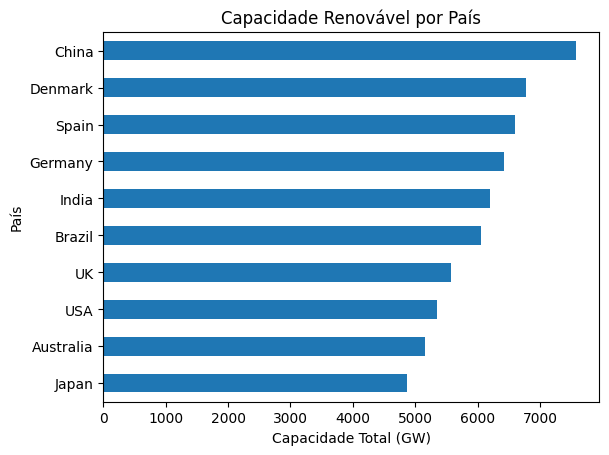

In [53]:
df.groupby("Country")["Total_Renewable_Capacity_GW"].sum().sort_values().plot(kind="barh")
plt.title("Capacidade Renovável por País")
plt.xlabel("Capacidade Total (GW)")
plt.ylabel("País")
plt.show()

In [54]:
df_paises = df.groupby("Country")["Total_Renewable_Capacity_GW"].sum().reset_index().sort_values(
    "Total_Renewable_Capacity_GW", ascending=False
)

df_paises

,Country,Total_Renewable_Capacity_GW
2,China,7570.19
3,Denmark,6777.64
7,Spain,6591.69
4,Germany,6416.74
5,India,6198.90
1,Brazil,6050.65
8,UK,5570.94
9,USA,5345.61
0,Australia,5158.04
6,Japan,4861.52


China lidera o ranking global, seguida por países europeus como Dinamarca e Espanha, mostrando forte investimento em energia limpa.

### Energia solar vs Eólica (Tendência)

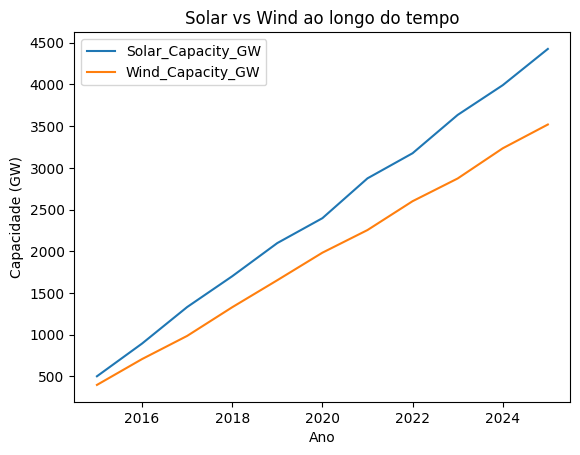

In [55]:
df.groupby("Year")[["Solar_Capacity_GW", "Wind_Capacity_GW"]].sum().plot()
plt.title("Solar vs Wind ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Capacidade (GW)")
plt.show()

In [56]:
df_solar_wind = df.groupby("Year")[["Solar_Capacity_GW", "Wind_Capacity_GW"]].sum().reset_index()

df_solar_wind

,Year,Solar_Capacity_GW,Wind_Capacity_GW
0,2015,501.53,397.99
1,2016,893.70,707.77
2,2017,1331.21,985.37
3,2018,1700.55,1329.16
4,2019,2098.24,1653.05
5,2020,2396.52,1982.95
6,2021,2873.97,2254.30
7,2022,3174.93,2600.06
8,2023,3634.19,2872.39
9,2024,3990.77,3234.25


Ambas as fontes apresentam crescimento paralelo, com destaque para expansão acelerada após 2020.

### Correlação entre variáveis

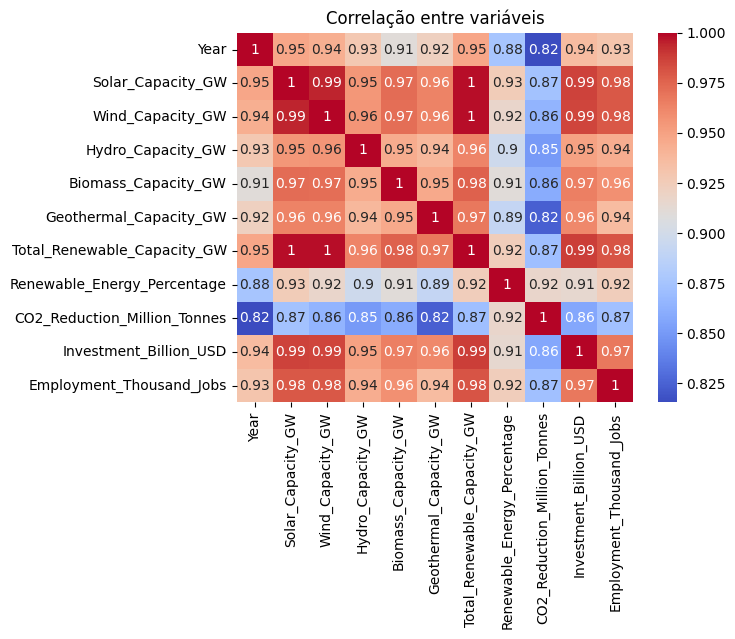

In [57]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis")
plt.show()

In [58]:
df_corr = df.corr(numeric_only=True)

df_corr

,Year,Solar_Capacity_GW,Wind_Capacity_GW,Hydro_Capacity_GW,Biomass_Capacity_GW,Geothermal_Capacity_GW,Total_Renewable_Capacity_GW,Renewable_Energy_Percentage,CO2_Reduction_Million_Tonnes,Investment_Billion_USD,Employment_Thousand_Jobs
Year,1.000000,0.947701,0.943052,0.928283,0.910260,0.921867,0.947913,0.875595,0.815409,0.936248,0.930510
Solar_Capacity_GW,0.947701,1.000000,0.994556,0.954594,0.972191,0.963712,0.998462,0.925421,0.873521,0.986343,0.979385
Wind_Capacity_GW,0.943052,0.994556,1.000000,0.955721,0.971691,0.963643,0.998037,0.916455,0.863769,0.986243,0.979696
Hydro_Capacity_GW,0.928283,0.954594,0.955721,1.000000,0.945086,0.938401,0.963216,0.897468,0.850046,0.949733,0.943989
Biomass_Capacity_GW,0.910260,0.972191,0.971691,0.945086,1.000000,0.946031,0.976379,0.910086,0.859394,0.965032,0.957565
Geothermal_Capacity_GW,0.921867,0.963712,0.963643,0.938401,0.946031,1.000000,0.967999,0.891559,0.823645,0.961554,0.935973
Total_Renewable_Capacity_GW,0.947913,0.998462,0.998037,0.963216,0.976379,0.967999,1.000000,0.923926,0.871320,0.988031,0.980720
Renewable_Energy_Percentage,0.875595,0.925421,0.916455,0.897468,0.910086,0.891559,0.923926,1.000000,0.916974,0.914342,0.923633
CO2_Reduction_Million_Tonnes,0.815409,0.873521,0.863769,0.850046,0.859394,0.823645,0.871320,0.916974,1.000000,0.857131,0.872331
Investment_Billion_USD,0.936248,0.986343,0.986243,0.949733,0.965032,0.961554,0.988031,0.914342,0.857131,1.000000,0.967785


## Insights

Forte correlação positiva entre capacidade instalada, investimento e redução de CO₂.

### Top países em energia renovável

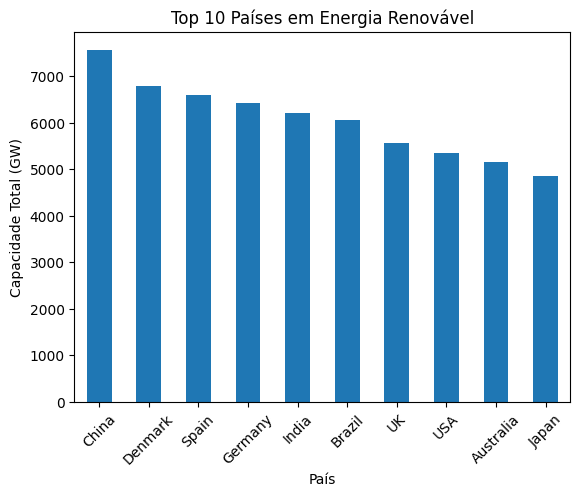

In [59]:
top_countries = df.groupby("Country")["Total_Renewable_Capacity_GW"].sum().sort_values(ascending=False)
top_countries.head(10).plot(kind="bar")
plt.title("Top 10 Países em Energia Renovável")
plt.xlabel("País")
plt.ylabel("Capacidade Total (GW)")
plt.xticks(rotation=45)
plt.show()

In [60]:
df_top10 = df.groupby("Country")["Total_Renewable_Capacity_GW"].sum().reset_index().sort_values(
    "Total_Renewable_Capacity_GW", ascending=False
).head(10)

df_top10

,Country,Total_Renewable_Capacity_GW
2,China,7570.19
3,Denmark,6777.64
7,Spain,6591.69
4,Germany,6416.74
5,India,6198.90
1,Brazil,6050.65
8,UK,5570.94
9,USA,5345.61
0,Australia,5158.04
6,Japan,4861.52


Países asiáticos e europeus dominam o topo, refletindo liderança em políticas energéticas sustentáveis.

### Evolução global da energia renovável

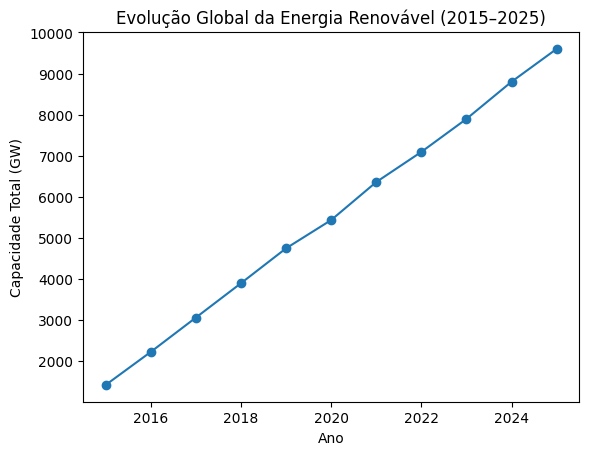

In [61]:
df.groupby("Year")["Total_Renewable_Capacity_GW"].sum().plot(marker="o")
plt.title("Evolução Global da Energia Renovável (2015–2025)")
plt.xlabel("Ano")
plt.ylabel("Capacidade Total (GW)")
plt.show()

In [62]:
df_evolucao = df.groupby("Year")["Total_Renewable_Capacity_GW"].sum().reset_index()

df_evolucao

,Year,Total_Renewable_Capacity_GW
0,2015,1424.52
1,2016,2227.77
2,2017,3062.65
3,2018,3898.53
4,2019,4747.66
5,2020,5435.22
6,2021,6359.56
7,2022,7092.72
8,2023,7895.53
9,2024,8799.26


O crescimento mostra uma aceleração constante da transição energética global ao longo da última década.

### Mix de fontes energéticas

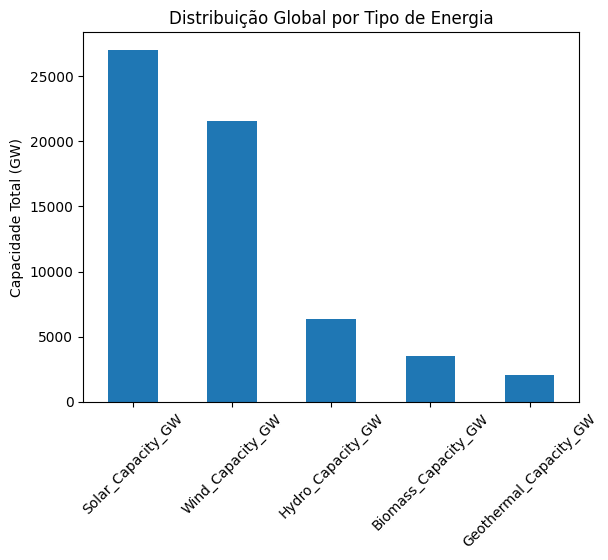

In [63]:
df[["Solar_Capacity_GW","Wind_Capacity_GW","Hydro_Capacity_GW",
    "Biomass_Capacity_GW","Geothermal_Capacity_GW"]].sum().plot(kind="bar")
plt.title("Distribuição Global por Tipo de Energia")
plt.ylabel("Capacidade Total (GW)")
plt.xticks(rotation=45)
plt.show()

In [64]:
df_mix = df[[
    "Solar_Capacity_GW",
    "Wind_Capacity_GW",
    "Hydro_Capacity_GW",
    "Biomass_Capacity_GW",
    "Geothermal_Capacity_GW"
]].sum().reset_index()

df_mix.columns = ["Energy_Type", "Total_Capacity_GW"]

df_mix

,Energy_Type,Total_Capacity_GW
0,Solar_Capacity_GW,27020.76
1,Wind_Capacity_GW,21536.48
2,Hydro_Capacity_GW,6384.42
3,Biomass_Capacity_GW,3512.79
4,Geothermal_Capacity_GW,2087.28


Energia solar e eólica dominam a matriz global, representando a maior parte da capacidade instalada.

### Relação investimento vs capacidade

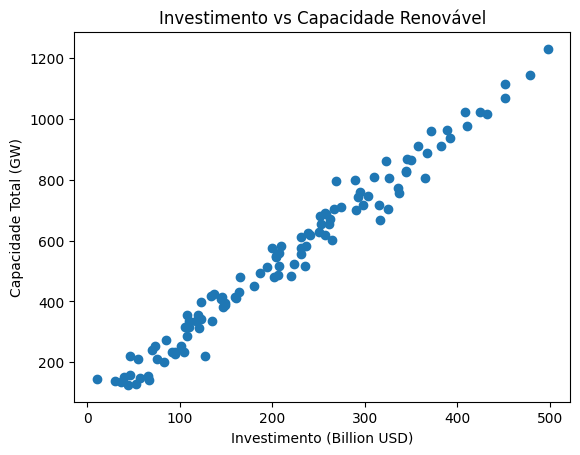

In [65]:
plt.scatter(df["Investment_Billion_USD"], df["Total_Renewable_Capacity_GW"])
plt.title("Investimento vs Capacidade Renovável")
plt.xlabel("Investimento (Billion USD)")
plt.ylabel("Capacidade Total (GW)")
plt.show()

In [66]:
df_invest = df.groupby("Country")[[
    "Investment_Billion_USD",
    "Total_Renewable_Capacity_GW"
]].sum().reset_index()

df_invest

,Country,Investment_Billion_USD,Total_Renewable_Capacity_GW
0,Australia,1961.39,5158.04
1,Brazil,2390.39,6050.65
2,China,3054.04,7570.19
3,Denmark,2706.65,6777.64
4,Germany,2553.74,6416.74
5,India,2461.09,6198.90
6,Japan,1823.35,4861.52
7,Spain,2618.24,6591.69
8,UK,2230.28,5570.94
9,USA,2015.37,5345.61


Países com maiores investimentos tendem a apresentar maior capacidade energética, indicando forte correlação entre capital e expansão energética.

### Relação CO₂ vs energia renovável

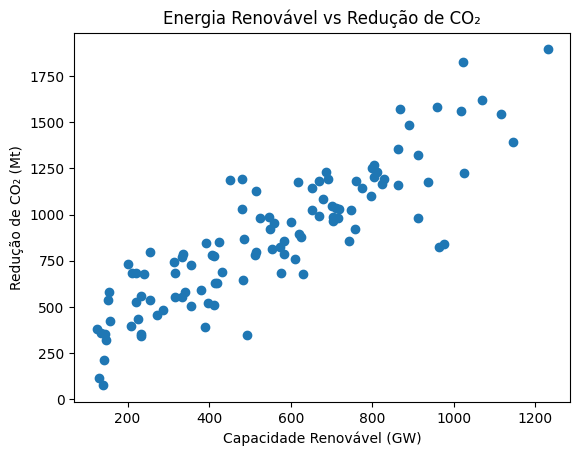

In [67]:
plt.scatter(df["Total_Renewable_Capacity_GW"], df["CO2_Reduction_Million_Tonnes"])
plt.title("Energia Renovável vs Redução de CO₂")
plt.xlabel("Capacidade Renovável (GW)")
plt.ylabel("Redução de CO₂ (Mt)")
plt.show()

In [68]:
df_co2 = df.groupby("Country")[[
    "Total_Renewable_Capacity_GW",
    "CO2_Reduction_Million_Tonnes"
]].sum().reset_index()

df_co2

,Country,Total_Renewable_Capacity_GW,CO2_Reduction_Million_Tonnes
0,Australia,5158.04,9256.97
1,Brazil,6050.65,8929.46
2,China,7570.19,11623.43
3,Denmark,6777.64,10582.45
4,Germany,6416.74,9624.78
5,India,6198.90,8809.90
6,Japan,4861.52,7903.61
7,Spain,6591.69,11227.46
8,UK,5570.94,9175.27
9,USA,5345.61,8952.05


O aumento da capacidade renovável está diretamente associado à redução significativa das emissões de carbono.

#Conclusão


A análise do dataset de transição energética entre 2015 e 2025 evidencia um crescimento consistente e acelerado da capacidade global de energia renovável ao longo do período analisado.

Os resultados demonstram que a expansão das fontes renováveis, especialmente solar e eólica, é o principal motor dessa transformação, representando a maior parte da capacidade instalada no cenário global.

A análise por país indica forte concentração do desenvolvimento em economias líderes, como China, países europeus e Estados Unidos, sugerindo que fatores econômicos e estratégicos influenciam diretamente o avanço da matriz energética limpa.

Além disso, foi identificada uma relação positiva entre investimento em energia renovável e capacidade instalada, confirmando que países que investem mais apresentam maior expansão energética.

Outro ponto relevante é a forte correlação entre aumento da capacidade renovável e redução das emissões de CO₂, reforçando o impacto ambiental positivo da transição energética.


## Hipóteses analisadas

- Países com maior investimento possuem maior capacidade de energia renovável ✔
- O crescimento da energia renovável está diretamente ligado à redução de CO₂ ✔
- Solar e eólica são as principais fontes de expansão energética global ✔
- Existe concentração do avanço energético em países economicamente mais desenvolvidos ✔

## Consideração final

Os dados reforçam que a transição energética global está em progresso contínuo, impulsionada por investimento, inovação e políticas ambientais. No entanto, ainda há desigualdade entre países, indicando que a transição não ocorre de forma uniforme no cenário mundial.

## Preparação para o Power BI


Preparar os dados para visualização no Power BI, criando versões organizadas e agregadas do dataset para análise por país e por ano.

Nesta etapa, transformamos os dados brutos em estruturas mais adequadas para dashboards, facilitando a criação de KPIs, rankings e análises temporais.

### Base principal (limpa)

In [69]:
df_final = df.copy()


### Base agregada por país (ranking completo)

In [70]:
df_country = df_final.groupby("Country").agg({
    "Total_Renewable_Capacity_GW": "sum",
    "Investment_Billion_USD": "sum",
    "CO2_Reduction_Million_Tonnes": "sum",
    "Employment_Thousand_Jobs": "sum"
}).reset_index()

### Base agregada por ano (tendência)

In [71]:
df_year = df_final.groupby("Year").agg({
    "Total_Renewable_Capacity_GW": "sum",
    "Investment_Billion_USD": "sum",
    "CO2_Reduction_Million_Tonnes": "sum",
    "Employment_Thousand_Jobs": "sum"
}).reset_index()

### Exportar arquivos para Power BI

In [72]:
df_final.to_csv("energy_transition_clean.csv", index=False)
df_country.to_csv("energy_by_country.csv", index=False)
df_year.to_csv("energy_by_year.csv", index=False)

### Download dos arquivos

In [73]:
from google.colab import files
files.download("energy_transition_clean.csv")
files.download("energy_by_country.csv")
files.download("energy_by_year.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>